In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import jieba
import nltk
from nltk.corpus import stopwords
import re

In [2]:
# Load CSVs
df_cn = pd.read_csv('../douban_reviews.csv')
df_en = pd.read_csv('../imdb_reviews.csv')

# Download English stopwords if needed
nltk.download('stopwords')
eng_stopwords = set(stopwords.words('english'))
eng_stopwords = set(open('../text_processing/english_stopwords.txt', encoding='utf-8').read().split())

#load in Chinese stopwords
zh_stopwords = set(open('../text_processing/chinese_stopwords.txt', encoding='utf-8').read().split())

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/elimarx/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<Axes: xlabel='title'>

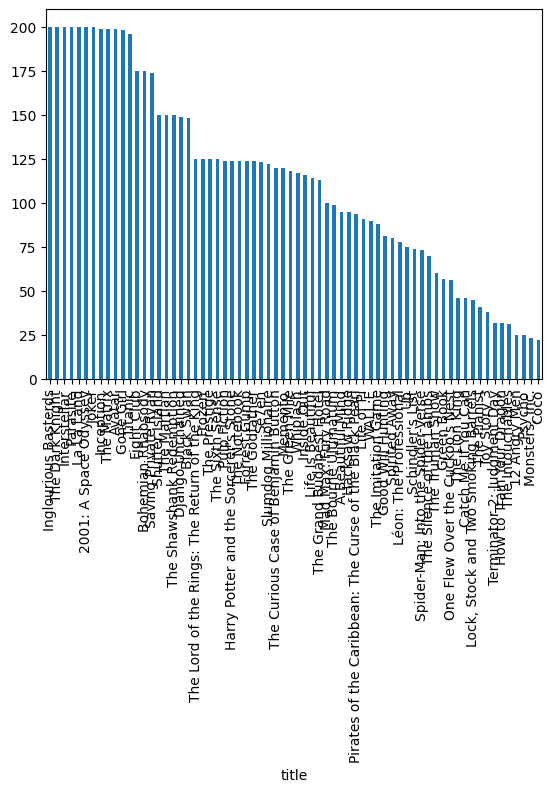

In [7]:
df_en['title'].value_counts().plot.bar()

<Axes: xlabel='title'>

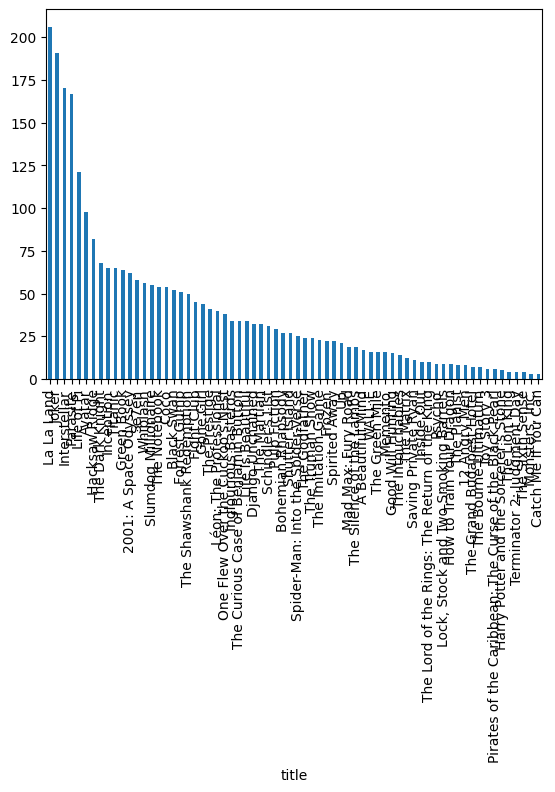

In [8]:
df_cn['title'].value_counts().plot.bar()

In [17]:
# Chinese preprocessing
def clean_chinese(text):
    text = re.sub(r"[^\u4e00-\u9fa5]", "", str(text))  # Keep only Chinese
    words = jieba.lcut(text)
    words = [word for word in words if word not in zh_stopwords]
    return ' '.join(words)

# English preprocessing
def clean_english(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = [w for w in text.split() if w not in eng_stopwords]
    return ' '.join(words)

# Apply preprocessing
df_cn['clean_comment'] = df_cn['review_text'].apply(clean_chinese)
df_en['clean_comment'] = df_en['comment'].apply(clean_english)

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/m_/hhg0dx_j62qbf4m6rdt4_3qc0000gn/T/jieba.cache
Loading model cost 0.256 seconds.
Prefix dict has been built successfully.


In [18]:
comments = df_cn["clean_comment"].dropna().tolist()

In [19]:
comments1 = df_en["clean_comment"].dropna().tolist()

In [20]:
from sentence_transformers import SentenceTransformer

# Use a multilingual model or a specific Chinese one
model = SentenceTransformer("shibing624/text2vec-base-chinese")
# For more accurate results with Chinese: "shibing624/text2vec-base-chinese"

embeddings = model.encode(comments, show_progress_bar=True)

/Users/elimarx/miniconda3/lib/python3.13/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange
/Users/elimarx/miniconda3/lib/python3.13/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/Users/elimarx/miniconda3/lib/python3.13/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/Users/elimarx/miniconda3/lib/python3.13/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0

In [21]:
embedding = embeddings

In [22]:
#do clustering
from sklearn.cluster import KMeans

num_clusters = 6  # tweak this
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embedding)

df_cn['cluster'] = labels

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [24]:
# from BCEmbedding import EmbeddingModel

# model = EmbeddingModel("maidalun1020/bce-embedding-base_v1")
# embedding = model.encode(comments, lexicon_aware=True)

/Users/elimarx/miniconda3/lib/python3.13/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
05/27/2025 17:47:17 - [INFO] -BCEmbedding.models.EmbeddingModel->>>    Loading from `maidalun1020/bce-embedding-base_v1`.
05/27/2025 17:47:17 - [INFO] -BCEmbedding.models.EmbeddingModel->>>    Execute device: cpu;	 gpu num: 0;	 use fp16: False;	 embedding pooling type: cls;	 trust remote code: False
Extract embeddings:   0%|          | 0/11 [00:30<?, ?it/s]


KeyboardInterrupt: 

In [12]:
#print some random comments from each cluster
for cluster_num in sorted(df_cn['cluster'].unique()):
    print(f"\nCluster {cluster_num}:")
    sample_comments = df_cn[df_cn['cluster'] == cluster_num]['clean_comment'].sample(4, random_state=42)
    for comment in sample_comments:
        print(" -", comment)


Cluster 0:
 - 谢邀 刚 完 黑漫威 黑 重度 抑郁症 患者 现 基本 好转 个人 认为 小丑 整个 人物 塑造 故事 逻辑 失败 人物 动机 不合理 角色 转变 不合理 创作 团队 精神疾病 毫无 了解 打着 精神疾病 幌子 胡编乱造 强行 恶人 塑造成 英雄 手枪 这条线 细节 阐述 逻辑 不自洽 第一次 同事 兰道 枪 交给 亚瑟 隐约 看到 袋子 里 至少 有发 子弹 非常 熟悉 枪械 应该 已经 认出 枪 属于 半吊子 尚未 识别 出是 枪 第二次 亚瑟 家里 玩枪 此幕 没有 表现 亚瑟 装填 弹药 细节 特写镜头 看到 桌上 大约 发 子弹 全景 镜头 中子弹 摆放 位置 特写镜头 位置 一致 细节 不究 亚瑟 跳舞 误触 走火 掉 一发 子弹 第三次 看到 是从 亚瑟 裤腿 内掉 侧边 口袋 掉 推测 亚瑟 枪 插 腰带 腹部 之间 从枪 外形 大致 判断 净重 发弹 筒 属于 尺寸 枪械 净重 克 净重 克 三星 净重 约克 英寸 机械 硬盘 大约 也就是说 一把 手枪 重量 相当于 部 最新款 大屏幕 手机 重量 加 一块儿 想象 一下 随身带 部 最新款 旗舰 台 机器 绑 一起 揣 同一个 口袋 里 舒服 感觉 不到 可能 重量 足够 没系 腰带 裤子 扯掉 下去 绝对 不会 忽略 重 玩意儿 孤儿院 一幕 只能 两种 解释 亚瑟 故意 带进去 结合 剧情 毫无 理由 亚瑟 犯病 忘 身上 带枪 这是 目前 唯一 合理 解释 导演 编剧 强行 塑造 戏剧 冲突 忽略 逻辑 合理性 可能性 结合 全片 剧情 最大 第四次 地铁 杀掉 金融 男 第发 子弹 寸头 金融 男 正中 右额 第发 子弹 白衣 金融 男 心脏 左腹 一发 第发弹 卷发 金融 男 全部打 背部 地铁 杀人 这幕 亚瑟 没有 装弹 细节 发弹 筒 出发 子弹 明显 剧组 工作失误 第五次 剧情 暗示 托马斯 韦恩 为富不仁 地板 报纸 直接 标题 杀富 一场 新 运动 第六次 注意 两个 细节 亚瑟 沙发 拔枪 时枪 挂 衣服 没 拔出来 第二次 亚瑟 开枪 撞针 明确 击发 弹筒 没有 子弹 结合 剧情 亚瑟 应该 已经 清空 弹筒 第七次 亚瑟 枪 警探 枪 注意 旁边 面具 人用 手 直接 抓住 警探 持枪 手 已经 属于 严重 袭警 行为 好莱坞 电影 

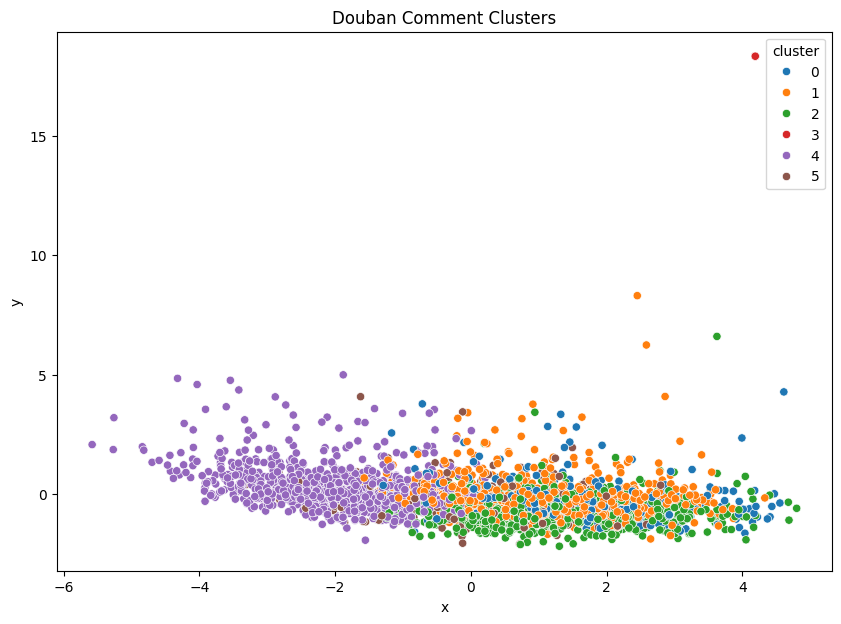

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

df_cn['x'] = reduced[:, 0]
df_cn['y'] = reduced[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_cn, x='x', y='y', hue='cluster', palette='tab10')
plt.title("Douban Comment Clusters")
plt.show()

In [14]:
from keybert import KeyBERT

kw_model = KeyBERT(model)
for i in range(num_clusters):
    cluster_comments = df_cn[df_cn['cluster'] == i]['clean_comment'].tolist()
    joined = " ".join(cluster_comments)
    keywords = kw_model.extract_keywords(joined, top_n=5)
    print(f"Cluster {i} keywords:", keywords)

Cluster 0 keywords: [('一塌糊涂', 0.6227), ('显露出', 0.6177), ('一个个', 0.6173), ('真是', 0.6164), ('有过', 0.614)]
Cluster 1 keywords: [('苟延残喘', 0.5964), ('般地', 0.5957), ('男二之口', 0.5837), ('人罗伊之口', 0.5813), ('一个个', 0.5804)]
Cluster 2 keywords: [('呆演', 0.6312), ('一个个', 0.6201), ('扯进', 0.6193), ('技傻白', 0.6193), ('第一个', 0.6177)]
Cluster 3 keywords: []
Cluster 4 keywords: [('戏大有', 0.6411), ('測電影', 0.6118), ('可说是', 0.6103), ('首第一个', 0.6101), ('冠冕堂皇', 0.6098)]
Cluster 5 keywords: [('有目共睹', 0.6481), ('精彩绝伦', 0.6438), ('堪称', 0.6348), ('一大群', 0.6337), ('这一作', 0.6299)]


In [21]:
df_cn['cluster'].value_counts()

cluster
4    915
1    575
2    570
5    327
0    297
3     21
Name: count, dtype: int64

In [ ]:
#just putting this somewhere so if i need to understand it again.
#this is the method i used to find the missing reviews in df with removed english that was sent to Annabelle
# Method 2: Compare by applying the same transformation to df_cn
# Since you mentioned it was likely removing \n or \r, let's try that
def simple_clean(text):
    if pd.isna(text):
        return text
    return str(text).replace('\n', '').replace('\r', '').replace('\r\n', '')

# Create a cleaned version of df_cn for comparison
df_cn_cleaned = df_cn.copy()
df_cn_cleaned['temp_clean'] = df_cn_cleaned['review_text'].apply(simple_clean)

# Find rows where the cleaned text doesn't match anything in df['clean_text']
df_cn_cleaned['exists_in_df'] = df_cn_cleaned['temp_clean'].isin(df['clean_text'])
missing_reviews_method2 = df_cn_cleaned[~df_cn_cleaned['exists_in_df']]